In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

n = 300

customer_id = np.arange(1001, 1001 + n)

subscription_type = np.random.choice(
    ["Basic", "Standard", "Premium"],
    n,
    p=[0.40, 0.40, 0.20]
)

tenure_months = np.random.randint(1, 49, n)

monthly_charge = np.where(
    subscription_type == "Basic",
    np.random.randint(300, 601, n),
    np.where(
        subscription_type == "Standard",
        np.random.randint(600, 1001, n),
        np.random.randint(1000, 1801, n)
    )
)

monthly_logins = np.random.randint(1, 31, n)

support_tickets = np.random.poisson(2, n)

watch_hours = np.round(
    np.random.uniform(2, 50, n), 1
)

payment_method = np.random.choice(
    ["Credit Card", "Debit Card", "UPI", "Net Banking"],
    n
)

auto_renewal = np.random.choice(
    ["Yes", "No"],
    n,
    p=[0.65, 0.35]
)

satisfaction_score = np.random.randint(1, 11, n)

churn_probability = (
    0.10
    + (tenure_months < 6) * 0.20
    + (monthly_logins < 8) * 0.20
    + (support_tickets >= 5) * 0.15
    + (satisfaction_score <= 4) * 0.20
    + (auto_renewal == "No") * 0.15
)

churn_probability = np.clip(churn_probability, 0, 0.90)

churn = np.random.binomial(1, churn_probability)

churn_status = np.where(
    churn == 1,
    "Yes",
    "No"
)

df = pd.DataFrame({
    "Customer_ID": customer_id,
    "Subscription_Type": subscription_type,
    "Tenure_Months": tenure_months,
    "Monthly_Charge": monthly_charge,
    "Monthly_Logins": monthly_logins,
    "Support_Tickets": support_tickets,
    "Watch_Hours": watch_hours,
    "Payment_Method": payment_method,
    "Auto_Renewal": auto_renewal,
    "Satisfaction_Score": satisfaction_score,
    "Churn": churn_status
})

df.head()

,Customer_ID,Subscription_Type,Tenure_Months,Monthly_Charge,Monthly_Logins,Support_Tickets,Watch_Hours,Payment_Method,Auto_Renewal,Satisfaction_Score,Churn
0,1001,Basic,45,381,2,5,40.8,Debit Card,Yes,1,Yes
1,1002,Premium,32,1645,8,4,4.8,UPI,No,10,No
2,1003,Standard,30,888,27,0,45.1,UPI,No,6,No
3,1004,Standard,47,830,13,1,33.2,Debit Card,Yes,9,No
4,1005,Basic,35,585,13,3,44.0,Net Banking,Yes,1,No


In [4]:
df.to_csv("customer_churn_raw.csv", index=False)

print("Raw churn dataset created successfully!")

Raw churn dataset created successfully!


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("Data types:")
print(df.dtypes)

print("Missing values:")
print(df.isnull().sum())

print("Churn distribution:")
print(df["Churn"].value_counts())
df.describe()


Rows: 300
Columns: 11
Data types:
Customer_ID             int64
Subscription_Type      object
Tenure_Months           int64
Monthly_Charge          int64
Monthly_Logins          int64
Support_Tickets         int64
Watch_Hours           float64
Payment_Method         object
Auto_Renewal           object
Satisfaction_Score      int64
Churn                  object
dtype: object
Missing values:
Customer_ID           0
Subscription_Type     0
Tenure_Months         0
Monthly_Charge        0
Monthly_Logins        0
Support_Tickets       0
Watch_Hours           0
Payment_Method        0
Auto_Renewal          0
Satisfaction_Score    0
Churn                 0
dtype: int64
Churn distribution:
Churn
No     212
Yes     88
Name: count, dtype: int64


,Customer_ID,Tenure_Months,Monthly_Charge,Monthly_Logins,Support_Tickets,Watch_Hours,Satisfaction_Score
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1150.500000,24.833333,767.276667,15.513333,1.943333,25.881667,5.273333
std,86.746758,13.318540,375.030576,8.731396,1.338942,14.011871,2.971203
min,1001.000000,1.000000,300.000000,1.000000,0.000000,2.000000,1.000000
25%,1075.750000,13.000000,478.000000,8.000000,1.000000,13.450000,3.000000
50%,1150.500000,26.000000,679.000000,15.000000,2.000000,26.250000,5.000000
75%,1225.250000,36.000000,945.750000,23.000000,3.000000,38.050000,8.000000
max,1300.000000,48.000000,1793.000000,30.000000,6.000000,50.000000,10.000000


In [7]:
churn_rate = (
    df["Churn"].value_counts(normalize=True) * 100
)

print(churn_rate)

Churn
No     70.666667
Yes    29.333333
Name: proportion, dtype: float64


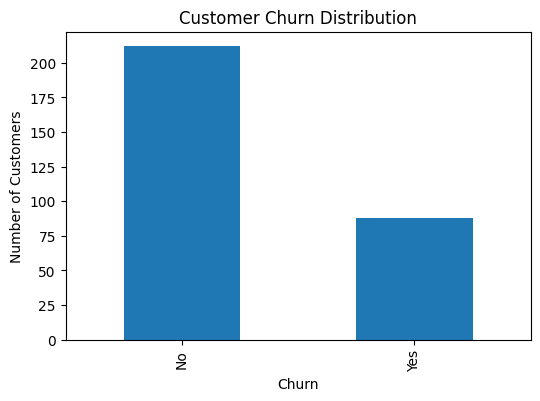

In [8]:
plt.figure(figsize=(6, 4))

df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
subscription_churn = pd.crosstab(
    df["Subscription_Type"],
    df["Churn"],
    normalize="index"
) * 100

print(subscription_churn)

Churn                     No        Yes
Subscription_Type                      
Basic              66.666667  33.333333
Premium            74.603175  25.396825
Standard           73.148148  26.851852


In [10]:
auto_churn = pd.crosstab(
    df["Auto_Renewal"],
    df["Churn"],
    normalize="index"
) * 100

print(auto_churn)

Churn                No        Yes
Auto_Renewal                      
No            61.739130  38.260870
Yes           76.216216  23.783784


In [11]:
satisfaction_churn = pd.crosstab(
    df["Satisfaction_Score"],
    df["Churn"],
    normalize="index"
) * 100

print(satisfaction_churn)

Churn                      No        Yes
Satisfaction_Score                      
1                   60.975610  39.024390
2                   60.000000  40.000000
3                   63.333333  36.666667
4                   51.515152  48.484848
5                   68.181818  31.818182
6                   79.411765  20.588235
7                   75.000000  25.000000
8                   68.000000  32.000000
9                   87.878788  12.121212
10                  96.428571   3.571429


In [12]:
churn_counts = df["Churn"].value_counts()

print("Customer Churn Counts:")
print(churn_counts)

churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"\nOverall Churn Rate: {churn_rate:.2f}%")

Customer Churn Counts:
Churn
No     212
Yes     88
Name: count, dtype: int64

Overall Churn Rate: 29.33%


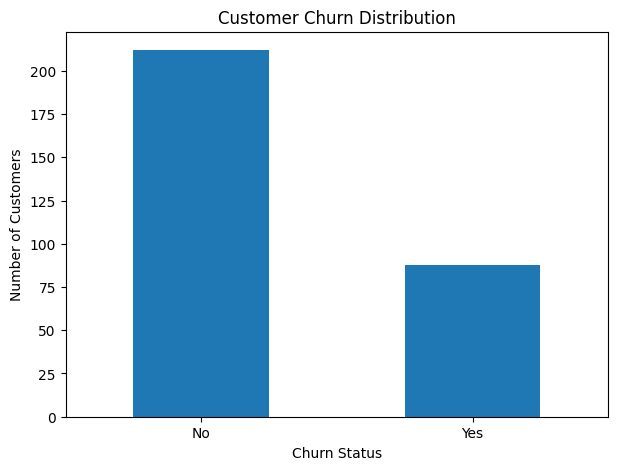

In [13]:
plt.figure(figsize=(7, 5))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [14]:
engagement_analysis = df.groupby("Churn")[
    ["Monthly_Logins", "Watch_Hours", "Support_Tickets"]
].mean().round(2)

display(engagement_analysis)

,Monthly_Logins,Watch_Hours,Support_Tickets
Churn,,,
No,16.90,26.18,1.94
Yes,12.17,25.17,1.95


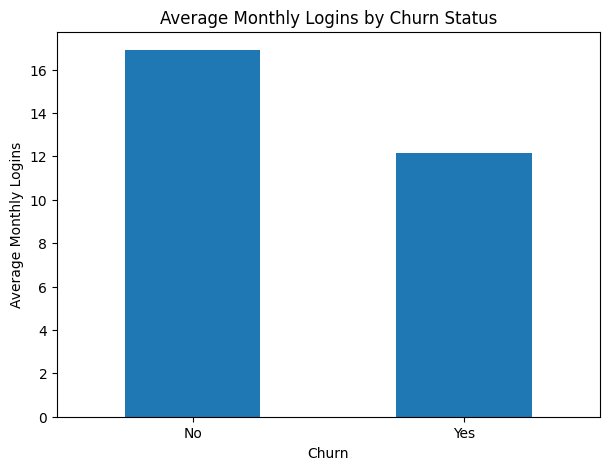

In [15]:
plt.figure(figsize=(7, 5))

df.groupby("Churn")["Monthly_Logins"].mean().plot(kind="bar")

plt.title("Average Monthly Logins by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Logins")
plt.xticks(rotation=0)

plt.show()

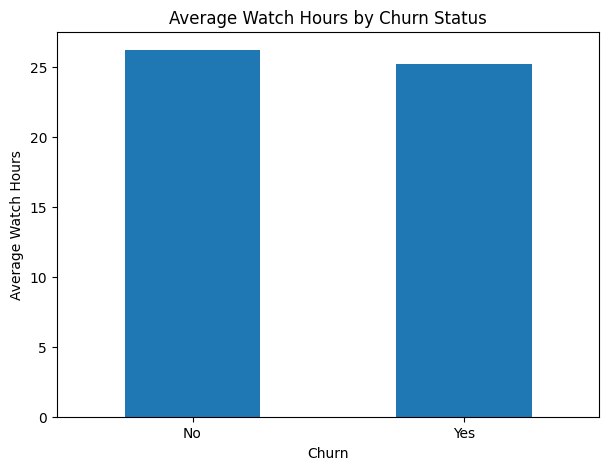

In [16]:
plt.figure(figsize=(7, 5))

df.groupby("Churn")["Watch_Hours"].mean().plot(kind="bar")

plt.title("Average Watch Hours by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Watch Hours")
plt.xticks(rotation=0)

plt.show()

Churn
No     5.74
Yes    4.16
Name: Satisfaction_Score, dtype: float64


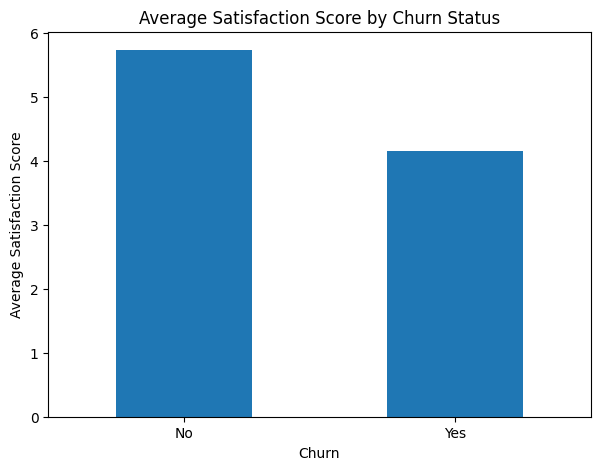

In [18]:
satisfaction_analysis = df.groupby("Churn")[
    "Satisfaction_Score"
].mean().round(2)

print(satisfaction_analysis)
plt.figure(figsize=(7, 5))

df.groupby("Churn")["Satisfaction_Score"].mean().plot(kind="bar")

plt.title("Average Satisfaction Score by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Satisfaction Score")
plt.xticks(rotation=0)

plt.show()

In [19]:
tenure_analysis = df.groupby("Churn")[
    "Tenure_Months"
].mean().round(2)

print(tenure_analysis)

Churn
No     25.89
Yes    22.28
Name: Tenure_Months, dtype: float64


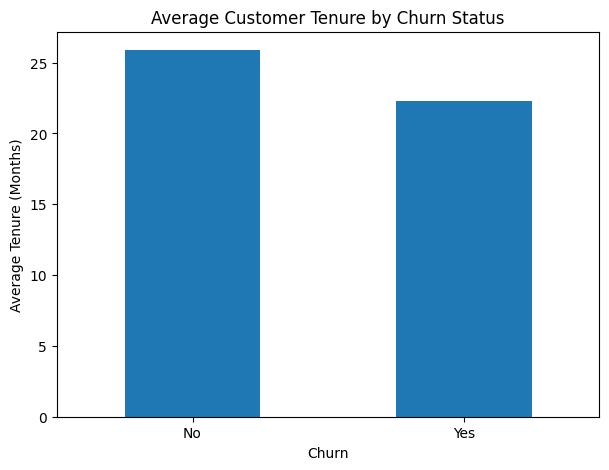

In [20]:
plt.figure(figsize=(7, 5))

df.groupby("Churn")["Tenure_Months"].mean().plot(kind="bar")

plt.title("Average Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)

plt.show()

Churn
No     1.94
Yes    1.95
Name: Support_Tickets, dtype: float64


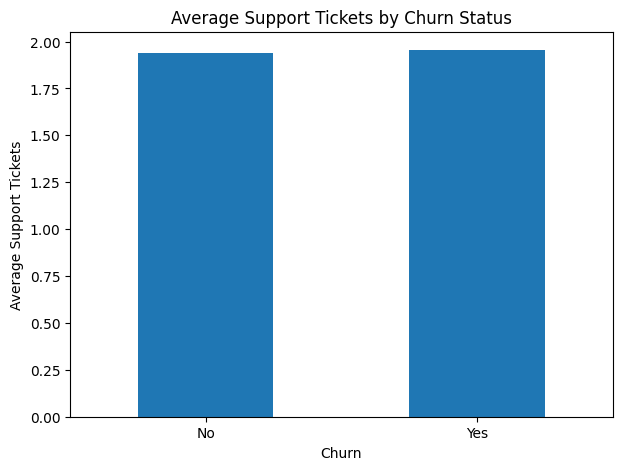

In [22]:
support_analysis = df.groupby("Churn")[
    "Support_Tickets"
].mean().round(2)

print(support_analysis)
plt.figure(figsize=(7, 5))

df.groupby("Churn")["Support_Tickets"].mean().plot(kind="bar")

plt.title("Average Support Tickets by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Support Tickets")
plt.xticks(rotation=0)

plt.show()

In [23]:
auto_renewal_analysis = pd.crosstab(
    df["Auto_Renewal"],
    df["Churn"],
    normalize="index"
) * 100

auto_renewal_analysis = auto_renewal_analysis.round(2)

display(auto_renewal_analysis)

Churn,No,Yes
Auto_Renewal,,
No,61.74,38.26
Yes,76.22,23.78


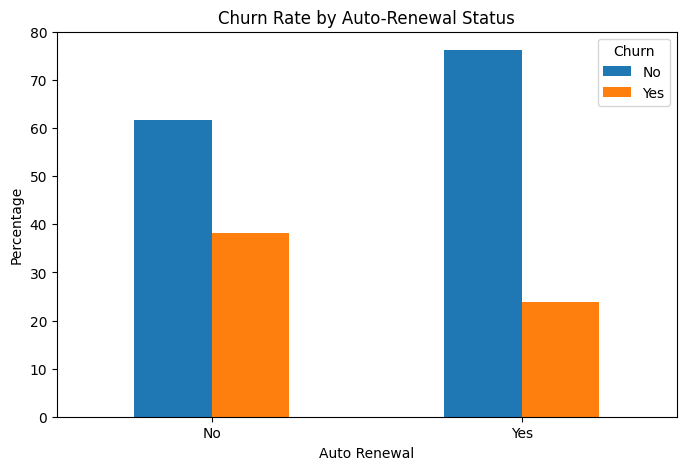

In [24]:
auto_renewal_churn = pd.crosstab(
    df["Auto_Renewal"],
    df["Churn"],
    normalize="index"
) * 100

auto_renewal_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Auto-Renewal Status")
plt.xlabel("Auto Renewal")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

Churn,No,Yes
Subscription_Type,,
Basic,66.67,33.33
Premium,74.60,25.40
Standard,73.15,26.85


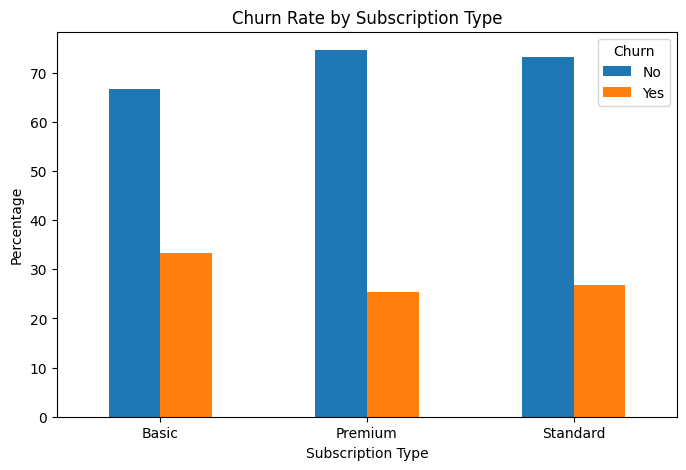

In [26]:
subscription_analysis = pd.crosstab(
    df["Subscription_Type"],
    df["Churn"],
    normalize="index"
) * 100

subscription_analysis = subscription_analysis.round(2)

display(subscription_analysis)
subscription_analysis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

Engagement_Level
High      143
Medium     89
Low        68
Name: count, dtype: int64


Churn,No,Yes
Engagement_Level,,
Low,48.53,51.47
Medium,73.03,26.97
High,79.72,20.28


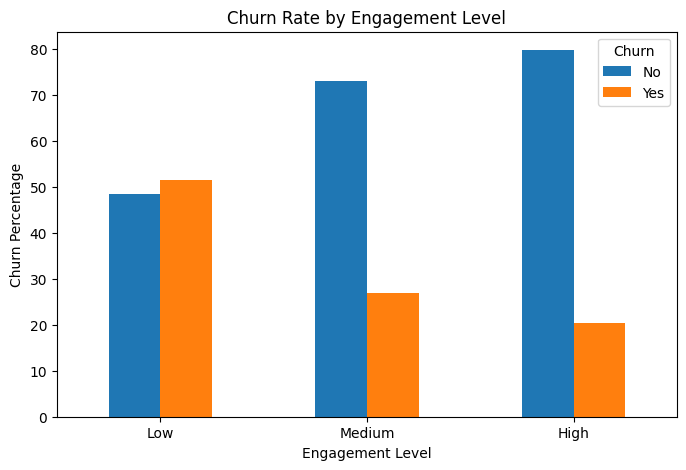

In [30]:
df["Engagement_Level"] = pd.cut(
    df["Monthly_Logins"],
    bins=[0, 7, 15, 30],
    labels=["Low", "Medium", "High"]
)
print(df["Engagement_Level"].value_counts())
engagement_churn = pd.crosstab(
    df["Engagement_Level"],
    df["Churn"],
    normalize="index"
) * 100

display(engagement_churn.round(2))
engagement_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)

plt.show()

In [34]:
df["Risk_Score"] = (
    (df["Monthly_Logins"] < 8).astype(int)
    + (df["Satisfaction_Score"] <= 4).astype(int)
    + (df["Auto_Renewal"] == "No").astype(int)
    + (df["Tenure_Months"] <= 6).astype(int)
    + (df["Support_Tickets"] >= 5).astype(int)
)
df["Risk_Level"] = pd.cut(
    df["Risk_Score"],
    bins=[-1, 1, 3, 5],
    labels=["Low", "Medium", "High"]
)
print(df["Risk_Level"].value_counts())
risk_churn = pd.crosstab(
    df["Risk_Level"],
    df["Churn"],
    normalize="index"
) * 100

display(risk_churn.round(2))

Risk_Level
Low       195
Medium    103
High        2
Name: count, dtype: int64


Churn,No,Yes
Risk_Level,,
Low,84.1,15.9
Medium,46.6,53.4
High,0.0,100.0


In [35]:
df.to_csv(
    "customer_churn_analysis.csv",
    index=False
)

print("Customer churn analysis dataset saved successfully!")

Customer churn analysis dataset saved successfully!


In [36]:
from google.colab import files

files.download("customer_churn_raw.csv")
files.download("customer_churn_analysis.csv")
files.download("Churn_Analysis.ipynb")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: Churn_Analysis.ipynb